In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

In [3]:
# Loading data
df = pd.read_csv('/Users/duncanpark/10-faers-foundation-model/data/processed/faers_combined_cleaned_pure_reactions.csv')
mapping_df = pd.read_csv('/Users/duncanpark/10-faers-foundation-model/data/processed/drug_name_mapping_updated.csv')

In [4]:
# Build a fast mapping dictionary for quick lookup: {messy_name: standardized_name}
mapping_df['messy_name_clean'] = mapping_df['messy_name'].astype(str).str.strip()
mapping_dict = dict(zip(mapping_df['messy_name_clean'], mapping_df['standardized_name']))

In [5]:
print("Processing drug combinations and mapping names...")
drug_pair_counter = Counter()

# Loop through every patient row's drug combination string
for combo_str in df['drug_combination'].dropna():
    # Split by semicolon and clean up outer whitespaces
    raw_drugs = [d.strip() for d in str(combo_str).split(';') if d.strip()]
    
    # Map each drug to its standardized name (fallback to original name if missing)
    mapped_drugs = []
    for d in raw_drugs:
        if "proactiv" in d.lower():
            continue
        standardized = mapping_dict.get(d)
        if pd.isna(standardized) or not standardized:
            mapped_drugs.append(d.lower())
        else:
            mapped_drugs.append(str(standardized).lower())
            
    # Deduplicate within the same report case and sort alphabetically
    unique_mapped_drugs = sorted(list(set(mapped_drugs)))
    
    # Extract sets of 2
    if len(unique_mapped_drugs) >= 2:
        drug_pair_counter.update(combinations(unique_mapped_drugs, 2))

# Convert top 10 drug pairs to a DataFrame
top_drug_pairs = pd.DataFrame(drug_pair_counter.most_common(10), columns=['Pair', 'Frequency'])
top_drug_pairs['Pair_Label'] = top_drug_pairs['Pair'].apply(lambda x: f"{x[0]} + {x[1]}")

Processing drug combinations and mapping names...


In [6]:
print("Processing side-effect pairs...")
# Automatically detect your reactions/side effects column name
se_col = [c for c in df.columns if 'pt' in c.lower() or 'react' in c.lower() or 'side' in c.lower() or 'adr' in c.lower()][0]
print(f"Detected side effect column: '{se_col}'")

# Check if side effects are also stored as a semicolon-separated string per row, or as separate rows
# We will check the first non-null row to decide how to split it safely
sample_se = str(df[se_col].dropna().iloc[0])

se_pair_counter = Counter()

if ';' in sample_se:
    # Scenario A: Side effects are also grouped with semicolons in a single row
    for se_str in df[se_col].dropna():
        unique_se = sorted(list(set([s.strip().lower() for s in str(se_str).split(';') if s.strip() and "proactiv" not in s.lower()])))        
        if len(unique_se) >= 2:
            se_pair_counter.update(combinations(unique_se, 2))
else:
    # Scenario B: Traditional format where side effects are separate rows per primaryid
    se_per_patient = df.groupby('primaryid')[se_col].apply(list)
    for se_list in se_per_patient:
        unique_se = sorted(list(set([str(s).strip().lower() for s in se_list if pd.notna(s) and "proactiv" not in str(s).lower()])))
        if len(unique_se) >= 2:
            se_pair_counter.update(combinations(unique_se, 2))

# Convert top 10 side-effect pairs to a DataFrame
top_se_pairs = pd.DataFrame(se_pair_counter.most_common(10), columns=['Pair', 'Frequency'])
top_se_pairs['Pair_Label'] = top_se_pairs['Pair'].apply(lambda x: f"{x[0]} + {x[1]}")

Processing side-effect pairs...
Detected side effect column: 'adrs'


Rendering charts...


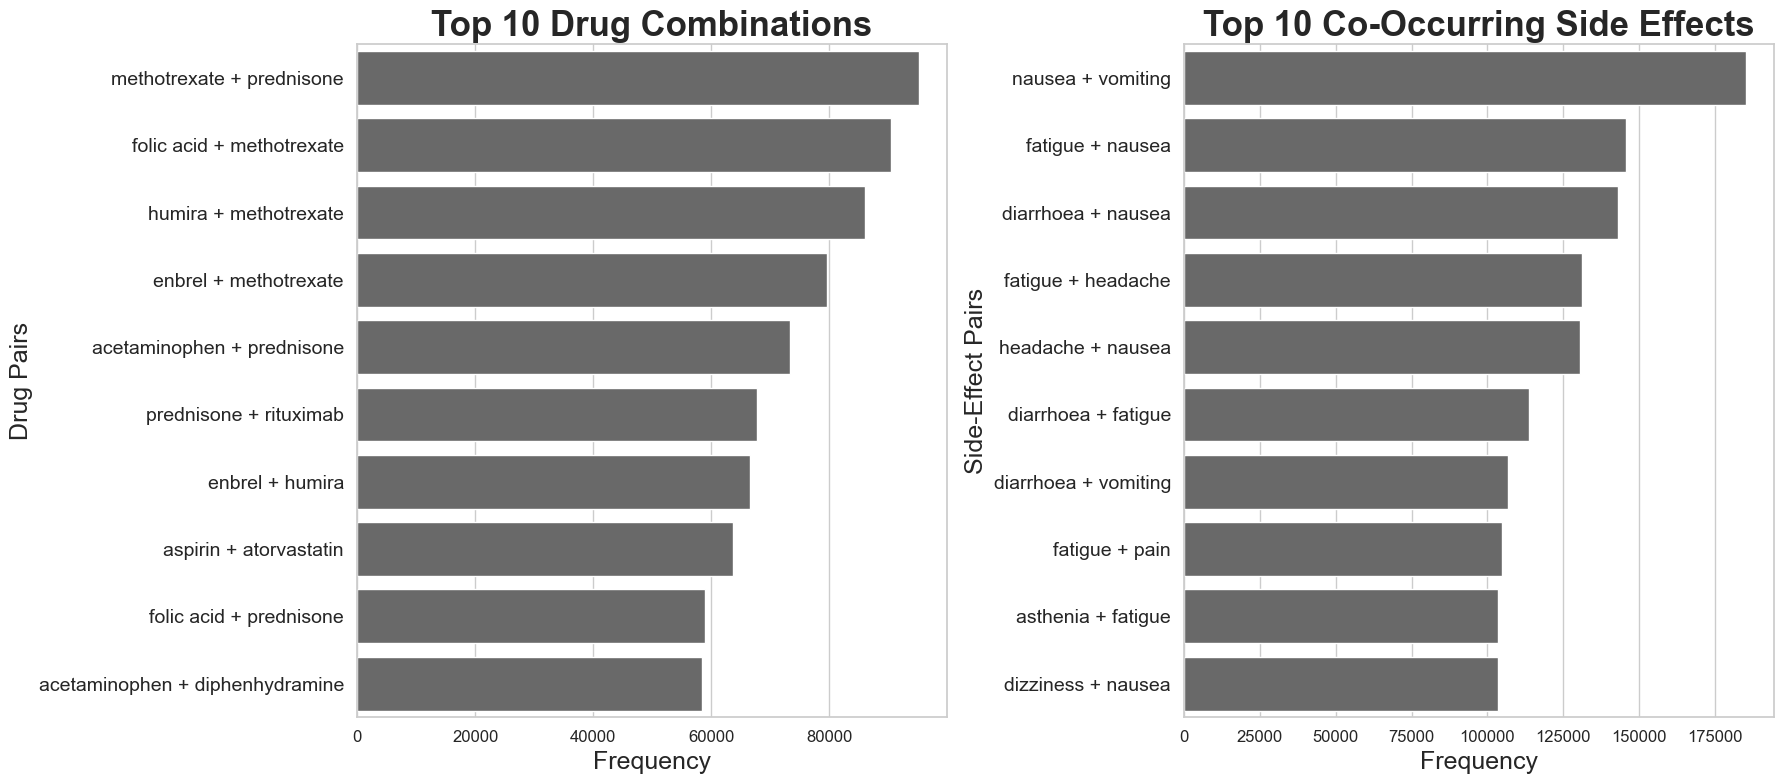

In [9]:
print("Rendering charts...")
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Chart 1: Mapped Drug Pairs
sns.barplot(x='Frequency', y='Pair_Label', data=top_drug_pairs, color='dimgrey', ax=axes[0])
axes[0].set_title('Top 10 Drug Combinations', fontsize=25, fontweight='bold')
axes[0].set_xlabel('Frequency', fontsize=18)
axes[0].set_ylabel('Drug Pairs', fontsize=18)

axes[0].tick_params(axis='y', labelsize=14)
axes[0].tick_params(axis='x', labelsize=12)

# Chart 2: Side Effect Pairs
sns.barplot(x='Frequency', y='Pair_Label', data=top_se_pairs, color='dimgrey', ax=axes[1])
axes[1].set_title('Top 10 Co-Occurring Side Effects', fontsize=25, fontweight='bold')
axes[1].set_xlabel('Frequency', fontsize=18)
axes[1].set_ylabel('Side-Effect Pairs', fontsize=18)

axes[1].tick_params(axis='y', labelsize=14)
axes[1].tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.show()